<a href="https://colab.research.google.com/github/ankur-357/MLnew/blob/main/SPORFlowResSpec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!sudo apt-get install build-essential cmake python3-dev libomp-dev libeigen3-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
cmake is already the newest version (3.22.1-1ubuntu1.22.04.1).
python3-dev is already the newest version (3.10.6-1~22.04).
python3-dev set to manually installed.
The following additional packages will be installed:
  libomp-14-dev libomp5-14
Suggested packages:
  libeigen3-doc libmpfrc++-dev libomp-14-doc
The following NEW packages will be installed:
  libeigen3-dev libomp-14-dev libomp-dev libomp5-14
0 upgraded, 4 newly installed, 0 to remove and 24 not upgraded.
Need to get 1,794 kB of archives.
After this operation, 18.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp5-14 amd64 1:14.0.0-1ubuntu1.1 [389 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libomp-14-dev amd64 1:14.0.0-1ubuntu1.1 [347 kB]
Get:3 http://archive.ubuntu.com/ubuntu 

In [ ]:
!sudo apt install pip

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'python3-pip' instead of 'pip'
The following additional packages will be installed:
  python3-setuptools python3-wheel
Suggested packages:
  python-setuptools-doc
The following NEW packages will be installed:
  python3-pip python3-setuptools python3-wheel
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 1,677 kB of archives.
After this operation, 8,967 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-setuptools all 59.6.0-1.2ubuntu0.22.04.1 [339 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-wheel all 0.37.1-2ubuntu0.22.04.1 [32.0 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 python3-pip all 22.0.2+dfsg-1ubuntu0.4 [1,305 kB]
Fetched 1,677 kB in 1s (1,892 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable 

In [ ]:
!pip install -e "git+https://github.com/neurodata/RerF.git@staging#egg=rerf&subdirectory=Python"

Obtaining rerf from git+https://github.com/neurodata/RerF.git@staging#egg=rerf&subdirectory=Python
  Cloning https://github.com/neurodata/RerF.git (to revision staging) to ./src/rerf
  Running command git clone --filter=blob:none --quiet https://github.com/neurodata/RerF.git /content/src/rerf
  Resolved https://github.com/neurodata/RerF.git to commit a7a3c7e6df457b722de86d7254f8a7724b27978f
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
  Using cached pybind11-2.11.1-py3-none-any.whl (227 kB)
  Running setup.py develop for rerf


In [ ]:
!pip install pyfp


In [ ]:
!pip install rerf

In [ ]:
!pip install pyforest

  Preparing metadata (setup.py) ... done
  Created wheel for pyforest: filename=pyforest-1.1.0-py2.py3-none-any.whl size=14606 sha256=dbf689961008adb015b964012651f9168639ea3feade6e8c34064a6a5136f09d
  Stored in directory: /root/.cache/pip/wheels/9e/7d/2c/5d2f5e62de376c386fd3bf5a8e5bd119ace6a9f48f49df6017
Successfully built pyforest


In [ ]:
!git clone https://github.com/neurodata/RerF.git

Cloning into 'RerF'...
remote: Enumerating objects: 9099, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 9099 (delta 46), reused 93 (delta 32), pack-reused 8974
Receiving objects: 100% (9099/9099), 111.07 MiB | 24.26 MiB/s, done.
Resolving deltas: 100% (5103/5103), done.
Updating files: 100% (2125/2125), done.


In [ ]:
cd RerF/Python

/content/RerF/Python


In [ ]:

!python setup.py clean --all

/usr/local/lib/python3.10/dist-packages/setuptools/__init__.py:84: _DeprecatedInstaller: setuptools.installer and fetch_build_eggs are deprecated.
!!

        ********************************************************************************
        Requirements should be satisfied by a PEP 517 installer.
        If you are using pip, you can try `pip install --use-pep517`.
        ********************************************************************************

!!
  dist.fetch_build_eggs(dist.setup_requires)
running clean
'build/lib.linux-x86_64-cpython-310' does not exist -- can't clean it
'build/bdist.linux-x86_64' does not exist -- can't clean it
'build/scripts-3.10' does not exist -- can't clean it


In [ ]:
!pip install -e .

Obtaining file:///content/RerF/Python
  Preparing metadata (setup.py) ... done
  Attempting uninstall: rerf
    Found existing installation: rerf 2.0.5
    Uninstalling rerf-2.0.5:
      Successfully uninstalled rerf-2.0.5
  Running setup.py develop for rerf


In [ ]:
"""
Example usage of RerF module.

Paths to dataset are relative from "Python" source directory.
"""

from multiprocessing import cpu_count

import numpy as np

from rerf.RerF import fastPredict, fastPredictPost, fastRerF

datatype = "iris"
# datatype = "mnist"

if datatype == "iris":
    datafile = "../packedForest/res/iris.csv"
    label_col = 4
elif datatype == "mnist":
    datafile = "../packedForest/res/mnist.csv"
    label_col = 0

print("loading data...")
X = np.genfromtxt(datafile, delimiter=",")
print("data loaded")

if datatype == "iris":
    feat_data = X[:, 0:4]  # iris
elif datatype == "mnist":
    feat_data = X[:, 1:]  # mnist

labels = X[:, label_col]

# forest = fastRerF(
#     CSVFile=datafile,
#     Ycolumn=label_col,
#     forestType="binnedBaseRerF",
#     trees=500,
#     numCores=cpu_count(),
# )
forest = fastRerF(
    X=feat_data, Y=labels, forestType="binnedBaseRerF", trees=500, numCores=cpu_count()
)

forest.printParameters()

# training predictions
predictions = fastPredict(feat_data, forest)
# print(predictions)

# training posterior predictions probabilities
post_pred = fastPredictPost(feat_data, forest)
# print(post_pred)

print("Error rate", np.mean(predictions != labels))

print("loading test data...")

if datatype == "iris":
    data_fname = "../packedForest/res/iris.csv"  # iris
elif datatype == "mnist":
    data_fname = "../packedForest/res/mnist_test.csv"  # mnist
test_X = np.genfromtxt(data_fname, delimiter=",")

print("data loaded")

if datatype == "iris":
    test_data = test_X[:, 0:4]  # iris
elif datatype == "mnist":
    test_data = test_X[:, 1:]  # mnist

test_pred = fastPredict(test_data, forest)

print("Error rate", np.mean(test_pred != test_X[:, label_col]))


loading data...
data loaded
numTreesInForest -> 500
maxDepth -> 2147483647
minParent -> 1
numClasses -> 3
numObservations -> 150
numFeatures -> 4
mtry -> 2
mtryMult -> 1.5
fractionOfFeaturesToTest -> -1
CSV file name -> 
columnWithY -> -1
Type of Forest -> binnedBaseRerF
binSize -> 0
binMin -> 0
numCores -> 2
seed -> 544833
numTreeBins -> 2
Error rate 0.0
loading test data...
data loaded
Error rate 0.0


In [ ]:
"""
Example shows usage of rerfClassifier class.

Based on https://www.datacamp.com/community/tutorials/random-forests-classifier-python
with rerfClassifier swapped out instead of sklearn's RandomForestClassifier
"""

from rerf.rerfClassifier import rerfClassifier

# Import scikit-learn dataset library
from sklearn import datasets

# Load dataset
iris = datasets.load_iris()


# print the label species(setosa, versicolor,virginica)
print(iris.target_names)

# print the names of the four features
print(iris.feature_names)

# Creating a DataFrame of given iris dataset.
import pandas as pd

data = pd.DataFrame(
    {
        "sepal length": iris.data[:, 0],
        "sepal width": iris.data[:, 1],
        "petal length": iris.data[:, 2],
        "petal width": iris.data[:, 3],
        "species": iris.target,
    }
)
print(data.head())

# Import train_test_split function
from sklearn.model_selection import train_test_split

X = data[["sepal length", "sepal width", "petal length", "petal width"]]  # Features
y = data["species"]  # Labels

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3
)  # 70% training and 30% test


# Create a Gaussian Classifier
clf = rerfClassifier(n_estimators=100)

print(clf)

# Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy, how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))


['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   sepal length  sepal width  petal length  petal width  species
0           5.1          3.5           1.4          0.2        0
1           4.9          3.0           1.4          0.2        0
2           4.7          3.2           1.3          0.2        0
3           4.6          3.1           1.5          0.2        0
4           5.0          3.6           1.4          0.2        0
rerfClassifier(n_estimators=100)
Accuracy: 0.9777777777777777


0.7531771271755628


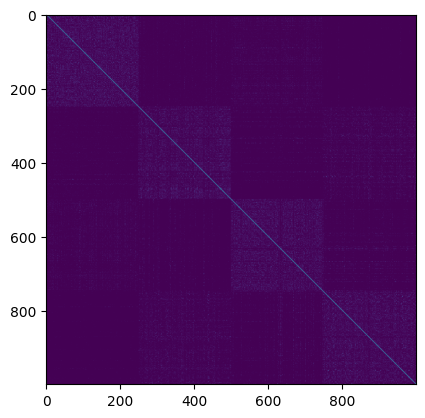

In [ ]:
from matplotlib import pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_classification
from sklearn.metrics import adjusted_rand_score
from rerf.urerf import UnsupervisedRandomForest
X, y = make_classification(
   n_samples=1000,
   n_features=4,
   n_informative=2,
   n_redundant=0,
   random_state=0,
   shuffle=False,
)
clf = UnsupervisedRandomForest(n_estimators=100, random_state=0)
clf.fit(X)
sim_mat = clf.transform()
plt.imshow(sim_mat)
cluster = AgglomerativeClustering(n_clusters=2)
predict_labels = cluster.fit_predict(sim_mat)
score = adjusted_rand_score(y, predict_labels)
print(score)

In [ ]:
from rerf.rerfClassifier import rerfClassifier
from sklearn.datasets import make_classification
X, y = make_classification(
   n_samples=1000,
   n_features=4,
   n_informative=2,
   n_redundant=0,
   random_state=0,
   shuffle=False,
)
clf = rerfClassifier(n_estimators=100, max_depth=3, random_state=0)
clf.fit(X, y)

rerfClassifier(feature_combinations=1.5, max_depth=2, max_features='auto',
            min_samples_split=1, n_estimators=100, n_jobs=None,
            projection_matrix='RerF', random_state=0)
print(clf.predict([[0, 0, 0, 0]]))
print(clf.predict_proba([[0, 0, 0, 0]]))

In [ ]:
import numpy as mp
import pandas as pd

# Specify the correct file path and header argument
data = pd.read_csv("/content/low_res_spectrometer.csv")


In [ ]:
data.head()

,sepal length,sepal width,petal length,petal width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
data.shape

(544, 103)

In [ ]:
data.columns

Index(['LRS-name', 'ID-type', 'Right-Ascension', 'Declination', 'Scale_Factor',
       'Blue_base_1', 'Blue_base_2', 'Red_base_1', 'Red_base_2',
       'blue-band-flux_1',
       ...
       'red-band-flux_41', 'red-band-flux_42', 'red-band-flux_43',
       'red-band-flux_44', 'red-band-flux_45', 'red-band-flux_46',
       'red-band-flux_47', 'red-band-flux_48', 'red-band-flux_49',
       'LRS-class'],
      dtype='object', length=103)

In [ ]:
data.isnull().sum()

LRS-name            13
ID-type             13
Right-Ascension     13
Declination         13
Scale_Factor        13
                    ..
red-band-flux_46    13
red-band-flux_47    13
red-band-flux_48    13
red-band-flux_49    13
LRS-class            0
Length: 103, dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Apply LabelEncoder
le = LabelEncoder()
data["LRS-name"] = le.fit_transform(data["LRS-name"])

In [ ]:
data.sample(5)

,LRS-name,ID-type,Right-Ascension,Declination,Scale_Factor,Blue_base_1,Blue_base_2,Red_base_1,Red_base_2,blue-band-flux_1,...,red-band-flux_41,red-band-flux_42,red-band-flux_43,red-band-flux_44,red-band-flux_45,red-band-flux_46,red-band-flux_47,red-band-flux_48,red-band-flux_49,LRS-class
123,123,0.0,15.781,-50.316,1.650000e-16,1441.0,1590.0,1003.0,1092.0,7438.4014,...,1205.74330,1236.86110,1239.04750,1210.92380,1349.62040,1236.06130,1276.91440,1302.61950,991.97614,27
403,403,4.0,20.158,-11.357,2.920000e-16,1106.0,1203.0,732.0,729.0,14690.1800,...,1065.62200,893.41230,885.20807,1208.32870,1007.95435,928.51310,854.04100,638.75507,903.89044,22
426,426,4.0,20.594,18.092,1.340000e-15,231.0,255.0,170.0,166.0,23853.1230,...,582.37010,492.11570,448.28720,526.63446,463.25485,358.33365,444.00757,409.94660,336.78775,17
88,88,4.0,14.946,66.132,1.100000e-15,344.0,373.0,155.0,172.0,25592.1430,...,558.66144,526.10535,366.22357,325.72238,468.26746,403.90390,379.33750,505.98400,393.88800,18
187,187,2.0,16.910,-42.247,1.530000e-15,207.0,196.0,95.0,93.0,15927.6430,...,814.95337,784.10930,771.15204,764.69870,779.38460,737.15580,732.32733,651.07090,634.85876,43


In [ ]:
# Assuming y_train is a pandas Series or DataFrame
data = data.fillna(data.mean())

In [ ]:
# Use the value_counts() function to get the counts of unique values
counts = data["LRS-class"].value_counts()

# Print the result
print(counts)

29    55
42    45
28    42
27    35
23    31
26    30
22    27
18    26
15    24
43    20
25    19
24    19
44    18
21    15
16    13
17    12
32    10
14    10
31     9
41     8
4      7
45     5
33     4
34     4
80     3
39     3
13     3
91     3
38     3
35     3
2      3
79     3
5      2
50     2
3      2
82     2
12     2
69     2
81     2
96     2
36     2
92     2
71     2
95     2
37     2
73     2
85     2
72     2
Name: LRS-class, dtype: int64


In [ ]:
data.isnull().sum()

LRS-name            0
ID-type             0
Right-Ascension     0
Declination         0
Scale_Factor        0
                   ..
red-band-flux_46    0
red-band-flux_47    0
red-band-flux_48    0
red-band-flux_49    0
LRS-class           0
Length: 103, dtype: int64

In [ ]:
# Using data.iloc[:,:-1].values we get the feature variables
X=data.iloc[:,:-1].values

# Using data.iloc[:,-1].values we get the target variable
y=data.iloc[:,-1].values


In [ ]:
data= data.fillna(data.mean())

In [ ]:
X.shape

(544, 102)

In [ ]:
y.shape

(544,)

In [ ]:
data.isnull().sum()

LRS-name            0
ID-type             0
Right-Ascension     0
Declination         0
Scale_Factor        0
                   ..
red-band-flux_46    0
red-band-flux_47    0
red-band-flux_48    0
red-band-flux_49    0
LRS-class           0
Length: 103, dtype: int64

In [ ]:
# from sklearn.preprocessing import LabelEncoder for performing Label Encoding
from sklearn.preprocessing import LabelEncoder
# Apply LabelEncoder
le = LabelEncoder()
y_new = le.fit_transform(y)
classes = le.classes_

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y_new, test_size=0.35, stratify=y)

In [ ]:
from rerf.rerfClassifier import rerfClassifier
clf = rerfClassifier(n_estimators=260, max_features=8, n_jobs = 2, random_state = 50)

In [ ]:
print(X_train.shape)

(353, 102)


In [ ]:
print(y_train.shape)

(353,)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
# Train the model using the training sets y_pred=clf.predict(X_test)
from time import time
# Measure training time
start_time = time()

clf.fit(X_train, y_train)
training_time = time() - start_time
print("Training time:", training_time)

# Measure testing time
start_time = time()

y_pred = clf.predict(X_test)

testing_time = time() - start_time
print("Testing time:", testing_time)

# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

y_pred_poba = clf.predict_proba(X_test)
# Model Accuracy, how often is the classifier correct?
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("F1-Score:", f1_score(y_test, y_pred, average="weighted"))
# Generate and print confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(y_test.shape)
print(y_pred_poba.shape)
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_poba, multi_class="ovr"))  # Assuming multi-class classification

Training time: 1.1309490203857422
Testing time: 0.045389413833618164
Accuracy: 0.5863874345549738
Precision: 0.5420579825856762
Recall: 0.5863874345549738
F1-Score: 0.5559718124552507
Confusion Matrix:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]]
(191,)
(191, 48)
ROC AUC Score: 0.8122706260710576


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


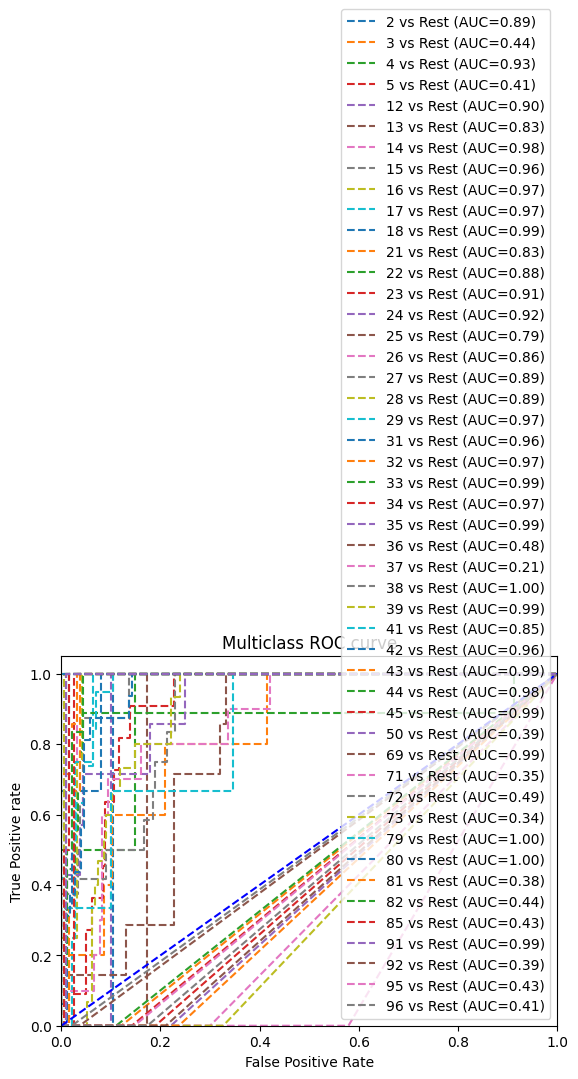

In [ ]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler=MinMaxScaler()
X_train_norm=min_max_scaler.fit_transform(X_train)
X_test_norm=min_max_scaler.fit_transform(X_test)

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve,auc

#Random Forest Classifier
#because we are dealing with multiclass data and so, the one versus rest strategy is used.
#learn to predict each class against the other.

RF=OneVsRestClassifier(rerfClassifier(n_estimators=300, max_features=8, n_jobs = 2, random_state = 50))
RF.fit(X_train_norm,y_train)
y_pred =RF.predict(X_test_norm)
pred_prob = RF.predict_proba(X_test_norm)

from sklearn.preprocessing import label_binarize
#binarize the y_values

y_test_binarized=label_binarize(y_test,classes=np.unique(y_test))

# roc curve for classes
fpr = {}
tpr = {}
thresh ={}
roc_auc = dict()

n_class = classes.shape[0]

for i in range(n_class):
    fpr[i], tpr[i], thresh[i] = roc_curve(y_test_binarized[:,i], pred_prob[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    # plotting
    plt.plot(fpr[i], tpr[i], linestyle='--',
             label='%s vs Rest (AUC=%0.2f)'%(classes[i],roc_auc[i]))

plt.plot([0,1],[0,1],'b--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.title('Multiclass ROC curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.legend(loc='lower right')
plt.show()


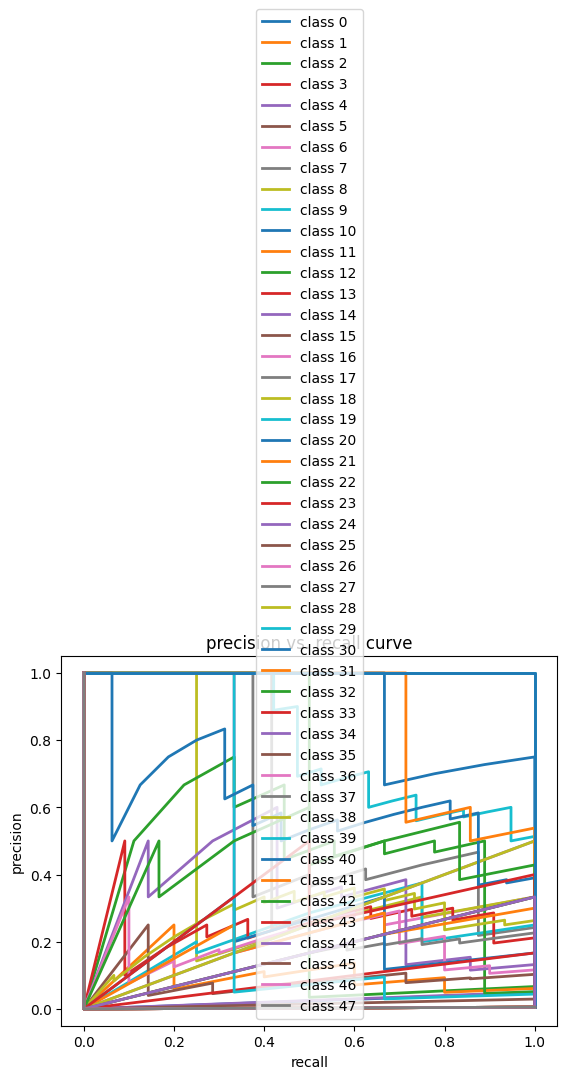

In [ ]:
# precision recall curve
from sklearn.metrics import precision_recall_curve
precision = dict()
recall = dict()
for i in range(n_class):
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:,i], pred_prob[:,i])
    plt.plot(recall[i], precision[i], lw=2, label='class {}'.format(i))

plt.xlabel("recall")
plt.ylabel("precision")
plt.legend(loc="best")
plt.title("precision vs. recall curve")
plt.show()